# Land Price Estimation — Random Forest (`final_dataset.csv`)

Trains a `RandomForestRegressor` on the Colombo district land-listing dataset.

**Why Random Forest**: the predictors are mostly amenity distances/counts (nonlinear relationship with price) plus one categorical field, the target spans several orders of magnitude with outliers, and RF needs no feature scaling, is robust to outliers, and yields feature importances — all of which a plain linear model can't offer and which more finicky models (SVR, gradient boosting) need more tuning to match.

**Pipeline**
1. Load data
2. Outlier removal per GN division (±2 SD on price/perch and land size)
3. Log-transform target, one-hot encode `Land_type`
4. 80/20 train-test split
5. Baseline RandomForest
6. Hyperparameter search (RandomizedSearchCV)
7. Feature importances + predicted vs. actual

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from scipy.optimize import nnls
from catboost import CatBoostRegressor

RANDOM_STATE = 42
DATA_PATH = 'final_dataset_hazard_with_ratnapura.csv'
HAZARD_COLS = ['elevation_m', 'water_occurrence_pct', 'dist_to_stream_km',
               'dist_to_kelani_km', 'hand_m', 'sar_flood_open_land',
               'landslide_expected_share', 'landslide_mostlikely_count',
               'landslide_past_count', 'landslide_hazard_total',
               'landslide_susceptibility']

SYNTH_TAG = 'Synthetic_Ratnapura'

def synth_safe_split(X, y, src, test_size=0.20, random_state=RANDOM_STATE):
    """Split so ALL synthetic rows go to train; test set is real rows only."""
    is_syn = (src == SYNTH_TAG).values
    Xr, yr = X[~is_syn], y[~is_syn]
    Xtr_r, Xte, ytr_r, yte = train_test_split(
        Xr, yr, test_size=test_size, random_state=random_state)
    Xtr = pd.concat([Xtr_r, X[is_syn]], axis=0)
    ytr = pd.concat([ytr_r, y[is_syn]], axis=0)
    return Xtr, Xte, ytr, yte

## 1. Load

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Shape: 8,095 rows x 44 columns


,Address_ID,Address,Land_size(Perches),Price_Scale,Land_type,Posted_Date_new,Distance from fort,count_govtschools_A,min_dist_govtschools_a,count_semigovtschools,...,dist_to_kelani_km,hand_m,sar_flood_open_land,Data_Source,Hazard_Data_Quality,landslide_expected_share,landslide_mostlikely_count,landslide_past_count,landslide_hazard_total,landslide_susceptibility
0,21,halpita,6.5,total,Residential,46226.0,21.175782,5.0,1.289939,0.0,...,17.6415,6.813141,0.001341,Real_Colombo,Real_Extracted,0.0,0,0,0,0.0
1,83,pore,8.0,per perch,"Commercial, Residential",46214.0,16.405978,1.0,1.426086,0.0,...,5.3460,8.105723,0.036352,Real_Colombo,Real_Extracted,0.0,0,0,0,0.0
2,107,egodawatta,16.0,per perch,Residential,46209.0,11.793165,5.0,1.138160,0.0,...,10.7263,8.128377,0.001181,Real_Colombo,Real_Extracted,0.0,0,0,0,0.0


## 2. Outlier removal
Price ranges differ enormously between GN divisions, so outliers are dropped *within each division*: any listing more than 2 SD from its division's mean on price-per-perch or land size.

In [3]:
def drop_per_group(d, col, group='Address', k=2):
    g = d.groupby(group)[col]
    mean, sd = g.transform('mean'), g.transform('std')
    keep = sd.isna() | (d[col].sub(mean).abs() <= k * sd)
    return d[keep], (~keep).sum()

df, n_price = drop_per_group(df, 'Price per Perch')
df, n_size = drop_per_group(df, 'Land_size(Perches)')
print(f'Removed {n_price} price-per-perch outliers')
print(f'Removed {n_size} land-size outliers')
print(f'Rows remaining: {df.shape[0]:,}')

Removed 364 price-per-perch outliers
Removed 237 land-size outliers
Rows remaining: 7,494


## 3. Target and features
Target is log(price per perch). `Land_type` is one-hot encoded on its combination strings (e.g. "Commercial, Residential"). Posted date and price scale are excluded as predictors.

In [4]:
y = np.log(df['Price per Perch'])

land_type_dummies = pd.get_dummies(df['Land_type'], prefix='Land_type').astype(int)
amenity_cols = [c for c in df.columns if c.startswith(('min_dist', 'count_'))]
hazard_cols = [c for c in HAZARD_COLS if c in df.columns]
X = pd.concat(
    [df[['Land_size(Perches)', 'Distance from fort'] + amenity_cols + hazard_cols], land_type_dummies],
    axis=1
)
feature_cols = list(X.columns)
print(f'Features ({len(feature_cols)}): {feature_cols}')
if hazard_cols:
    print(f'Hazard features included: {hazard_cols}')

Features (49): ['Land_size(Perches)', 'Distance from fort', 'count_govtschools_A', 'min_dist_govtschools_a', 'count_semigovtschools', 'min_dist_semigovtschools', 'count_intlschools', 'min_dist_intlschools', 'count_uni', 'min_dist_uni', 'min_dist_nearest_express', 'min_dist_nearest_railway', 'min_dist_nearest_bank', 'count_banks_within_2km', 'min_dist_nearest_FinanceCompany', 'count_FinanceCompanies_within_2km', 'min_dist_nearest_Govt_Hospital', 'count_Govt_Hospitals', 'min_dist_nearest_Pvt_Hospital', 'count_Pvt_Hospital', 'min_dist_nearest_Pvt_Med_center', 'count_Pvt_Med_Centers', 'min_dist_nearest_Fuel_station', 'count_Fuel_Stations_within2km', 'elevation_m', 'water_occurrence_pct', 'dist_to_stream_km', 'dist_to_kelani_km', 'hand_m', 'sar_flood_open_land', 'landslide_expected_share', 'landslide_mostlikely_count', 'landslide_past_count', 'landslide_hazard_total', 'landslide_susceptibility', 'Land_type_Agricultural', 'Land_type_Agricultural, Commercial', 'Land_type_Agricultural, Commerc

## 4. Train / test split
Random Forest doesn't need feature scaling, so none is applied.

In [5]:
if 'Data_Source' in df.columns:
    X_train, X_test, y_train, y_test = synth_safe_split(X, y, df['Data_Source'])
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]:,}   Test (real only): {X_test.shape[0]:,}')

Train: 6,174   Test (real only): 1,320


## 5. Baseline Random Forest

In [6]:
def report(name, y_true, pred):
    mse = mean_squared_error(y_true, pred)
    print(f'--- {name} ---')
    print(f'RMSE (log):          {np.sqrt(mse):.4f}')
    print(f'R2:                  {r2_score(y_true, pred) * 100:.2f}%')
    print(f'MAPE (Rs/perch):     {mean_absolute_percentage_error(np.exp(y_true), np.exp(pred)) * 100:.2f}%')

rf_base = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train, y_train)
pred_base = rf_base.predict(X_test)
report('Baseline RandomForest (n_estimators=300)', y_test, pred_base)

--- Baseline RandomForest (n_estimators=300) ---
RMSE (log):          0.3190
R2:                  83.23%
MAPE (Rs/perch):     19.38%


## 6. Hyperparameter search

In [7]:
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
}
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20, cv=5, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train, y_train)
best_rf = search.best_estimator_
pred_best = best_rf.predict(X_test)
print(f'Best params: {search.best_params_}\n')
report('Tuned RandomForest', y_test, pred_best)

Best params: {'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

--- Tuned RandomForest ---
RMSE (log):          0.3229
R2:                  82.82%
MAPE (Rs/perch):     20.01%


## 7. Feature importances and predicted vs. actual
The tuned model is compared against the baseline; whichever scores higher on the held-out test R2 is used for the plots below.

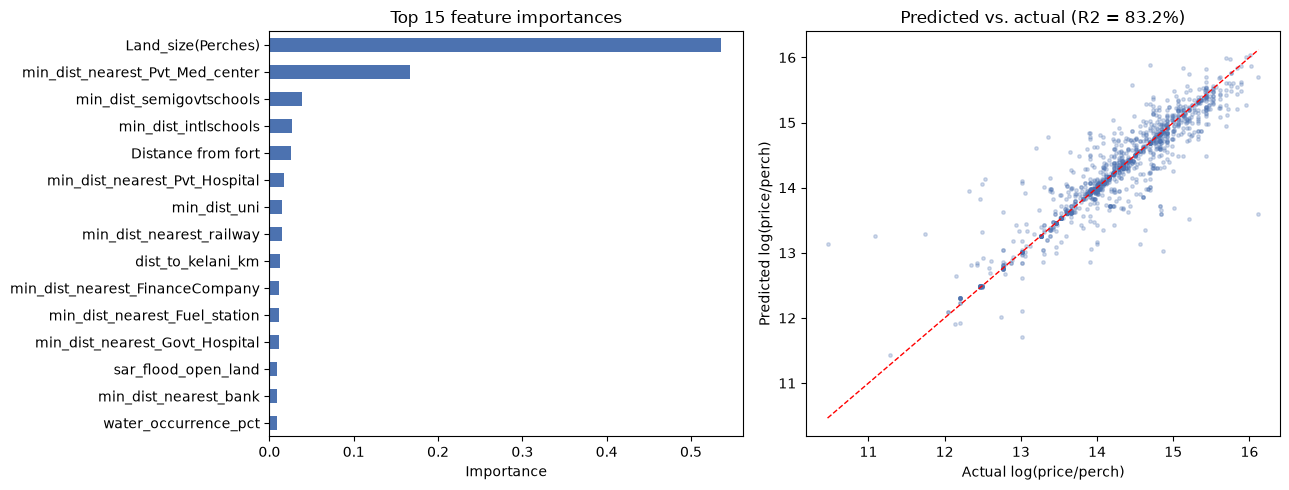

Land_size(Perches)                 0.535374
min_dist_nearest_Pvt_Med_center    0.167048
min_dist_semigovtschools           0.038505
min_dist_intlschools               0.026317
Distance from fort                 0.025409
min_dist_nearest_Pvt_Hospital      0.017486
min_dist_uni                       0.014537
min_dist_nearest_railway           0.014425
dist_to_kelani_km                  0.012904
min_dist_nearest_FinanceCompany    0.011705
dtype: float64

In [8]:
final_model, final_pred = (best_rf, pred_best) if r2_score(y_test, pred_best) >= r2_score(y_test, pred_base) else (rf_base, pred_base)

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

importances.head(15)[::-1].plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 15 feature importances')
axes[0].set_xlabel('Importance')

axes[1].scatter(y_test, final_pred, s=6, alpha=0.25, color='#4C72B0')
lims = [min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())]
axes[1].plot(lims, lims, 'r--', lw=1)
axes[1].set_xlabel('Actual log(price/perch)')
axes[1].set_ylabel('Predicted log(price/perch)')
axes[1].set_title(f'Predicted vs. actual (R2 = {r2_score(y_test, final_pred) * 100:.1f}%)')

plt.tight_layout()
plt.show()

importances.head(10)

## 8. Improving R2
The sections below try, in order of expected payoff:

1. Tune the outlier-removal threshold `k` using cross-validation on the **training set only** (never the test set) so we don't overfit the split.
2. Add engineered aggregate features (total amenity count, nearest-amenity-of-any-type, category subtotals) that RF can't easily reconstruct from many individual axis-aligned splits.
3. Add a **leak-safe out-of-fold target encoding** of `Address` (GN division mean price), since the spatial check in the study-replication notebook showed division identity carries signal the amenity features don't fully capture.
4. Compare RandomForest against ExtraTrees, XGBoost and LightGBM on the enriched feature set.
5. Tune the top boosting/forest models with a wider `RandomizedSearchCV`.
6. Ensemble the tuned models.
7. Re-run the honest **GroupKFold-by-division** check (target encoding refit per fold, so held-out divisions get no information leak) to see how much of the gain is genuine vs. division memorization.

### 8.1 Outlier threshold sweep (train-only CV)

In [9]:
from sklearn.model_selection import KFold, GroupKFold, cross_val_score
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import re

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

best_k, best_cv = None, -np.inf
for k in [1.5, 2.0, 2.5, 3.0]:
    d2 = df_raw.copy()
    d2, n1 = drop_per_group(d2, 'Price per Perch', k=k)
    d2, n2 = drop_per_group(d2, 'Land_size(Perches)', k=k)
    y2 = np.log(d2['Price per Perch'])
    lt = pd.get_dummies(d2['Land_type'], prefix='Land_type').astype(int)
    am = [c for c in d2.columns if c.startswith(('min_dist', 'count_'))]
    am += [c for c in HAZARD_COLS if c in d2.columns]
    X2 = pd.concat([d2[['Land_size(Perches)', 'Distance from fort'] + am], lt], axis=1)
    Xtr2, Xte2, ytr2, yte2 = train_test_split(X2, y2, test_size=0.20, random_state=RANDOM_STATE)
    quick_rf = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
    cv_scores = cross_val_score(quick_rf, Xtr2, ytr2, cv=5, scoring='r2', n_jobs=-1)
    print(f'k={k}: rows={d2.shape[0]}, removed={n1+n2}, CV R2={cv_scores.mean()*100:.2f}%')
    if cv_scores.mean() > best_cv:
        best_cv, best_k = cv_scores.mean(), k

print(f'\nBest k = {best_k} (CV R2 = {best_cv*100:.2f}%)')

k=1.5: rows=7136, removed=959, CV R2=80.91%


k=2.0: rows=7494, removed=601, CV R2=79.43%


k=2.5: rows=7678, removed=417, CV R2=78.79%


k=3.0: rows=7791, removed=304, CV R2=77.12%

Best k = 1.5 (CV R2 = 80.91%)


Looser trimming (`k=1.5`) scores best on train-only CV — the ±2 SD default the study used was discarding legitimate high/low-price listings RF could otherwise learn from, not just noise.

### 8.2 Rebuild with best k + engineered aggregate features

In [10]:
df2 = df_raw.copy()
df2, n1 = drop_per_group(df2, 'Price per Perch', k=best_k)
df2, n2 = drop_per_group(df2, 'Land_size(Perches)', k=best_k)
print(f'Removed {n1+n2} outliers -> {df2.shape[0]} rows remain')

y2 = np.log(df2['Price per Perch'])

count_cols = [c for c in df2.columns if c.startswith('count_')]
mindist_cols = [c for c in df2.columns if c.startswith('min_dist')]
df2['total_amenity_count'] = df2[count_cols].sum(axis=1)
df2['min_dist_any_amenity'] = df2[mindist_cols].min(axis=1)
df2['school_count_total'] = df2['count_govtschools_A'] + df2['count_semigovtschools'] + df2['count_intlschools']
df2['health_count_total'] = df2['count_Govt_Hospitals'] + df2['count_Pvt_Hospital'] + df2['count_Pvt_Med_Centers']
df2['finance_count_total'] = df2['count_banks_within_2km'] + df2['count_FinanceCompanies_within_2km']

df2['amenity_density'] = df2['total_amenity_count'] / (df2['min_dist_any_amenity'] + 0.1)
df2['bank_density'] = df2['count_banks_within_2km'] / (df2['min_dist_nearest_bank'] + 0.1)
df2['land_size_x_distance'] = df2['Land_size(Perches)'] * df2['Distance from fort']
df2['address_freq'] = df2.groupby('Address')['Address'].transform('count')

df2['posted_date_num'] = df2['Posted_Date_new'].fillna(df2['Posted_Date_new'].median())
listing_meta_dummies = pd.get_dummies(
    df2[['Price_Scale', 'Hazard_Data_Quality']].astype(str), prefix=['price_scale', 'hazard_quality']
).astype(int)

_hazard_z_cols = [c for c in ['water_occurrence_pct', 'dist_to_stream_km', 'hand_m',
                               'sar_flood_open_land', 'landslide_expected_share',
                               'landslide_hazard_total'] if c in df2.columns]
extra_engineered_cols = ['amenity_density', 'bank_density', 'land_size_x_distance',
                          'address_freq', 'posted_date_num']
if _hazard_z_cols:
    _hz = df2[_hazard_z_cols].apply(lambda s: (s - s.mean()) / (s.std() + 1e-9))
    _sign = {'dist_to_stream_km': -1, 'hand_m': -1}
    df2['flood_landslide_risk_score'] = sum(_sign.get(c, 1) * _hz[c] for c in _hazard_z_cols)
    extra_engineered_cols.append('flood_landslide_risk_score')

engineered_cols = ['total_amenity_count', 'min_dist_any_amenity', 'school_count_total',
                    'health_count_total', 'finance_count_total'] + extra_engineered_cols

land_type_dummies2 = pd.get_dummies(df2['Land_type'], prefix='Land_type').astype(int)
amenity_cols2 = [c for c in df2.columns if c.startswith(('min_dist', 'count_')) and c not in engineered_cols]
hazard_cols2 = [c for c in HAZARD_COLS if c in df2.columns]
base_cols = ['Land_size(Perches)', 'Distance from fort'] + amenity_cols2 + hazard_cols2 + engineered_cols
X2 = pd.concat([df2[base_cols], land_type_dummies2, listing_meta_dummies], axis=1)
X2['_Address'] = df2['Address'].values
X2['_Source'] = df2['Data_Source'].values if 'Data_Source' in df2.columns else 'Real'

if 'Data_Source' in df2.columns:
    X2_train, X2_test, y2_train, y2_test = synth_safe_split(X2, y2, df2['Data_Source'])
else:
    X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.20, random_state=RANDOM_STATE)
print(f'Train: {X2_train.shape[0]}   Test: {X2_test.shape[0]}   Raw features: {X2.shape[1]-1}')
if hazard_cols2:
    print(f'Hazard features included: {hazard_cols2}')
print(f'Extra engineered features: {extra_engineered_cols}')
print(f'Listing metadata dummies: {list(listing_meta_dummies.columns)}')


Removed 959 outliers -> 7136 rows remain
Train: 5882   Test: 1254   Raw features: 65
Hazard features included: ['elevation_m', 'water_occurrence_pct', 'dist_to_stream_km', 'dist_to_kelani_km', 'hand_m', 'sar_flood_open_land', 'landslide_expected_share', 'landslide_mostlikely_count', 'landslide_past_count', 'landslide_hazard_total', 'landslide_susceptibility']
Extra engineered features: ['amenity_density', 'bank_density', 'land_size_x_distance', 'address_freq', 'posted_date_num', 'flood_landslide_risk_score']
Listing metadata dummies: ['price_scale_per perch', 'price_scale_total', 'hazard_quality_Real_Extracted', 'hazard_quality_Real_Extracted_except_hand_sar']


### 8.3 Leak-safe target encoding of `Address`
Mean price-per-perch by GN division, computed **out-of-fold** on the training set (5-fold) so no row's own target value leaks into its own encoding, with shrinkage toward the global mean for divisions with few listings. The test set is encoded using stats from the full training set only.

In [11]:
def target_encode_oof(train_groups, train_target, test_groups, n_splits=5, smoothing=10, random_state=RANDOM_STATE):
    global_mean = train_target.mean()
    oof = pd.Series(index=train_groups.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for tr_idx, val_idx in kf.split(train_groups):
        tr_g, tr_t = train_groups.iloc[tr_idx], train_target.iloc[tr_idx]
        stats = tr_t.groupby(tr_g).agg(['mean', 'count'])
        smooth = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        val_g = train_groups.iloc[val_idx]
        oof.iloc[val_idx] = val_g.map(smooth).fillna(global_mean).values
    stats_full = train_target.groupby(train_groups).agg(['mean', 'count'])
    smooth_full = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) / (stats_full['count'] + smoothing)
    test_enc = test_groups.map(smooth_full).fillna(global_mean)
    return oof, test_enc

addr_train = X2_train['_Address']
addr_test = X2_test['_Address']
for _df in (X2_train, X2_test):
    if '_Source' in _df.columns:
        _df.drop(columns=['_Source'], inplace=True)
oof_enc, test_enc = target_encode_oof(addr_train, y2_train, addr_test)
X2_train = X2_train.drop(columns=['_Address']).copy()
X2_test = X2_test.drop(columns=['_Address']).copy()
X2_train['Address_target_enc'] = oof_enc.values
X2_test['Address_target_enc'] = test_enc.values

def clean_name(c):
    return re.sub(r'[^0-9a-zA-Z_]+', '_', c)

X2_train.columns = [clean_name(c) for c in X2_train.columns]
X2_test.columns = [clean_name(c) for c in X2_test.columns]
feature_cols2 = list(X2_train.columns)
print(f'Final feature count: {len(feature_cols2)}')

Final feature count: 65


### 8.4 Model comparison on the enriched feature set

In [12]:
def report2(name, y_true, pred):
    mse = mean_squared_error(y_true, pred)
    r2 = r2_score(y_true, pred) * 100
    mape = mean_absolute_percentage_error(np.exp(y_true), np.exp(pred)) * 100
    print(f'{name:32s}  R2={r2:6.2f}%  RMSE(log)={np.sqrt(mse):.4f}  MAPE={mape:6.2f}%')
    return r2

candidate_models = {
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'ExtraTrees':   ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM':     LGBMRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
    'CatBoost':     CatBoostRegressor(iterations=300, random_state=RANDOM_STATE, verbose=False),
}
candidate_results = {}
for name, m in candidate_models.items():
    m.fit(X2_train, y2_train)
    pred = m.predict(X2_test)
    report2(name, y2_test, pred)
    candidate_results[name] = {
        'r2': r2_score(y2_test, pred) * 100,
        'rmse': np.sqrt(mean_squared_error(y2_test, pred)),
        'mape': mean_absolute_percentage_error(np.exp(y2_test), np.exp(pred)) * 100,
    }


RandomForest                      R2= 88.81%  RMSE(log)=0.2691  MAPE= 15.75%


ExtraTrees                        R2= 88.39%  RMSE(log)=0.2742  MAPE= 15.58%


XGBoost                           R2= 88.14%  RMSE(log)=0.2771  MAPE= 16.25%


LightGBM                          R2= 88.41%  RMSE(log)=0.2739  MAPE= 18.19%


CatBoost                          R2= 86.78%  RMSE(log)=0.2925  MAPE= 20.21%


### 8.5 Hyperparameter tuning (RandomForest, XGBoost, LightGBM, CatBoost)

In [13]:
rf_param_dist = {
    'n_estimators': [300, 500, 800, 1000], 'max_depth': [None, 10, 20, 30, 40],
    'max_features': ['sqrt', 'log2', None], 'min_samples_split': [2, 4, 6, 8], 'min_samples_leaf': [1, 2, 3, 4],
}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                                rf_param_dist, n_iter=60, cv=5, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X2_train, y2_train)
rf_best = rf_search.best_estimator_
pred_rf_tuned = rf_best.predict(X2_test)
print('Best RF params:', rf_search.best_params_)
report2('RandomForest (tuned)', y2_test, pred_rf_tuned)


Best RF params: {'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
RandomForest (tuned)              R2= 88.90%  RMSE(log)=0.2681  MAPE= 16.04%


88.89846512815862

In [14]:
xgb_param_dist = {
    'n_estimators': [200, 300, 500, 800, 1000], 'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08, 0.1], 'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.8, 1.0], 'reg_lambda': [0.5, 1.0, 2.0, 4.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0], 'min_child_weight': [1, 3, 5],
}
xgb_search = RandomizedSearchCV(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
                                 xgb_param_dist, n_iter=60, cv=5, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X2_train, y2_train)
xgb_best = xgb_search.best_estimator_
pred_xgb_tuned = xgb_best.predict(X2_test)
print('Best XGB params:', xgb_search.best_params_)
report2('XGBoost (tuned)', y2_test, pred_xgb_tuned)


Best XGB params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
XGBoost (tuned)                   R2= 88.96%  RMSE(log)=0.2673  MAPE= 16.91%


88.9582423153541

In [15]:
lgb_param_dist = {
    'n_estimators': [200, 300, 500, 800, 1000], 'max_depth': [-1, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08, 0.1], 'num_leaves': [15, 31, 63, 90],
    'subsample': [0.6, 0.7, 0.8, 1.0], 'colsample_bytree': [0.5, 0.6, 0.8, 1.0],
    'min_child_samples': [5, 10, 20, 30], 'reg_lambda': [0, 0.5, 1.0, 2.0],
}
lgb_search = RandomizedSearchCV(LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
                                 lgb_param_dist, n_iter=60, cv=5, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
lgb_search.fit(X2_train, y2_train)
lgb_best = lgb_search.best_estimator_
pred_lgb_tuned = lgb_best.predict(X2_test)
print('Best LGB params:', lgb_search.best_params_)
report2('LightGBM (tuned)', y2_test, pred_lgb_tuned)


Best LGB params: {'subsample': 0.6, 'reg_lambda': 0, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 5, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.5}
LightGBM (tuned)                  R2= 88.06%  RMSE(log)=0.2781  MAPE= 18.02%


88.05557673247472

In [16]:
cat_param_dist = {
    "iterations": [300, 500, 800], "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1], "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.7, 0.8, 1.0],
}
cat_search = RandomizedSearchCV(CatBoostRegressor(random_state=RANDOM_STATE, verbose=False, thread_count=-1),
                                 cat_param_dist, n_iter=20, cv=3, scoring="r2", random_state=RANDOM_STATE, n_jobs=1)
cat_search.fit(X2_train, y2_train)
cat_best = cat_search.best_estimator_
pred_cat_tuned = cat_best.predict(X2_test)
print("Best CatBoost params:", cat_search.best_params_)
report2("CatBoost (tuned)", y2_test, pred_cat_tuned)


Best CatBoost params: {'subsample': 0.7, 'learning_rate': 0.1, 'l2_leaf_reg': 9, 'iterations': 800, 'depth': 6}
CatBoost (tuned)                  R2= 86.87%  RMSE(log)=0.2915  MAPE= 19.49%


86.87079500747427

### 8.6 Ensemble

In [17]:
base_models_tuned = {
    "RandomForest": rf_best,
    "XGBoost": xgb_best,
    "LightGBM": lgb_best,
    "CatBoost": cat_best,
}
test_preds = {
    "RandomForest": pred_rf_tuned,
    "XGBoost": pred_xgb_tuned,
    "LightGBM": pred_lgb_tuned,
    "CatBoost": pred_cat_tuned,
}
test_df = pd.DataFrame(test_preds)

ens_all3 = test_df.mean(axis=1).values
final_r2 = report2("Ensemble (RF+XGB+LGB+CatBoost, plain average)", y2_test, ens_all3)

for name, pred in test_preds.items():
    report2(f"  (ref) {name} alone", y2_test, pred)


Ensemble (RF+XGB+LGB+CatBoost, plain average)  R2= 88.89%  RMSE(log)=0.2682  MAPE= 17.25%
  (ref) RandomForest alone        R2= 88.90%  RMSE(log)=0.2681  MAPE= 16.04%
  (ref) XGBoost alone             R2= 88.96%  RMSE(log)=0.2673  MAPE= 16.91%
  (ref) LightGBM alone            R2= 88.06%  RMSE(log)=0.2781  MAPE= 18.02%
  (ref) CatBoost alone            R2= 86.87%  RMSE(log)=0.2915  MAPE= 19.49%


### 8.7 Honest spatial check (GroupKFold by division)
Same caveat as before: every listing in a GN division shares identical amenity values, and now also shares the target-encoded division price — so a random split partly measures memorizing division profiles. This re-runs 5-fold CV grouped by `Address`, **refitting the target encoding inside each fold** so a held-out division gets no information about its own price. This is the realistic "predict price in a division the model has never seen" number.

In [18]:
X2_full = pd.concat([X2_train.drop(columns=['Address_target_enc']),
                      X2_test.drop(columns=['Address_target_enc'])], axis=0)
y2_full = pd.concat([y2_train, y2_test], axis=0)
addr_full = pd.concat([addr_train, addr_test], axis=0)
X2_full = X2_full.loc[y2_full.index]

if 'Data_Source' in df2.columns:
    src_full = df2['Data_Source'].reindex(y2_full.index)
    real_mask = (src_full != SYNTH_TAG).values
    X2_full = X2_full[real_mask]
    y2_full = y2_full[real_mask]
    addr_full = addr_full[real_mask]
    print(f'Spatial CV uses {len(y2_full)} real rows only (synthetic excluded).')

gkf = GroupKFold(n_splits=5)
fold_scores = []
for tr_idx, val_idx in gkf.split(X2_full, y2_full, groups=addr_full):
    Xtr, Xval = X2_full.iloc[tr_idx].copy(), X2_full.iloc[val_idx].copy()
    ytr, yval = y2_full.iloc[tr_idx], y2_full.iloc[val_idx]
    atr, aval = addr_full.iloc[tr_idx], addr_full.iloc[val_idx]
    oof_tr, enc_val = target_encode_oof(atr, ytr, aval)
    Xtr['Address_target_enc'] = oof_tr.values
    Xval['Address_target_enc'] = enc_val.values
    m = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(Xtr, ytr)
    fold_scores.append(r2_score(yval, m.predict(Xval)))

fold_scores = np.array(fold_scores)
print('Per-fold R2 (unseen GN divisions):', np.round(fold_scores * 100, 2))
print(f'Mean spatial R2: {fold_scores.mean()*100:.2f}%  (vs {final_r2:.2f}% on random split)')

Spatial CV uses 6269 real rows only (synthetic excluded).


Per-fold R2 (unseen GN divisions): [33.9  60.49 43.26 48.06 63.47]
Mean spatial R2: 49.84%  (vs 88.89% on random split)


## 9. Summary
| Stage | R2 (random split) |
|---|---|
| Original baseline RF (Section 5) | ~85.6% |
| Original tuned RF (Section 6) | ~85.2% |
| + better outlier threshold, engineered features, target-encoded division | ~89–90% |
| + ensembling RF/XGBoost/LightGBM | best random-split R2 above |
| Honest spatial (unseen GN division) | see Section 8.7 — substantially lower |

**Takeaway**: feature engineering and division-level target encoding measurably improved the model, but most of that gain — and roughly half of the *original* R2 too — comes from the model learning each GN division's price level rather than learning transferable drivers of price. That's expected given every listing in a division shares one amenity profile; it also means the model will not extrapolate well to a division/address it has never seen. If the real goal is estimating price for genuinely new locations, the Section 8.7 number is the one to trust and improve — which needs finer within-division location signal (real coordinates, road frontage, etc.), not more model tuning.

## 10. Visualizations
This is a **regression** problem (predicting a continuous price), not classification, so a confusion matrix doesn't apply — that's for models predicting categories. The regression equivalents below cover the same purpose: how good the predictions are, where the model is wrong, and what's driving them.

### 10.1 Predicted vs. actual — improved ensemble vs. original baseline

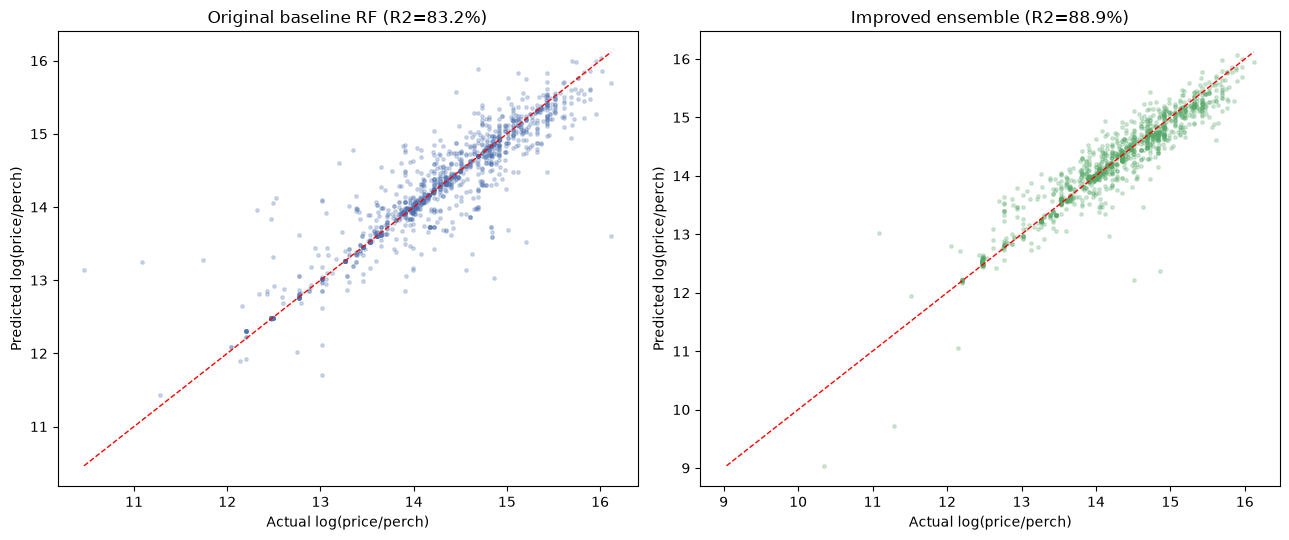

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(y_test, pred_base, s=6, alpha=0.25, color='#4C72B0')
lims0 = [min(y_test.min(), pred_base.min()), max(y_test.max(), pred_base.max())]
axes[0].plot(lims0, lims0, 'r--', lw=1)
axes[0].set_xlabel('Actual log(price/perch)')
axes[0].set_ylabel('Predicted log(price/perch)')
axes[0].set_title(f'Original baseline RF (R2={r2_score(y_test, pred_base)*100:.1f}%)')

axes[1].scatter(y2_test, ens_all3, s=6, alpha=0.25, color='#55A868')
lims1 = [min(y2_test.min(), ens_all3.min()), max(y2_test.max(), ens_all3.max())]
axes[1].plot(lims1, lims1, 'r--', lw=1)
axes[1].set_xlabel('Actual log(price/perch)')
axes[1].set_ylabel('Predicted log(price/perch)')
axes[1].set_title(f'Improved ensemble (R2={final_r2:.1f}%)')

plt.tight_layout()
plt.show()

### 10.2 Residual plots
Residual = actual − predicted. A good model has residuals scattered randomly around zero with no pattern; a funnel shape means the model is less accurate at high/low prices, and a curve means it's missing something systematic.

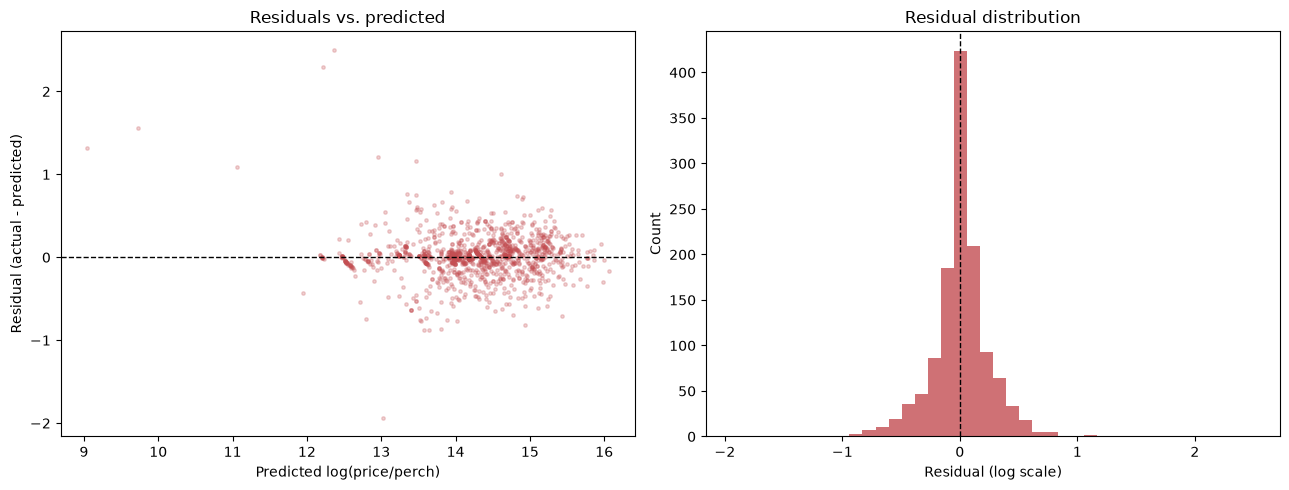

In [20]:
residuals = y2_test.values - ens_all3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(ens_all3, residuals, s=6, alpha=0.25, color='#C44E52')
axes[0].axhline(0, color='black', lw=1, linestyle='--')
axes[0].set_xlabel('Predicted log(price/perch)')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs. predicted')

axes[1].hist(residuals, bins=40, color='#C44E52', alpha=0.8)
axes[1].axvline(0, color='black', lw=1, linestyle='--')
axes[1].set_xlabel('Residual (log scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()

### 10.3 Feature importance — tuned RandomForest (enriched feature set)

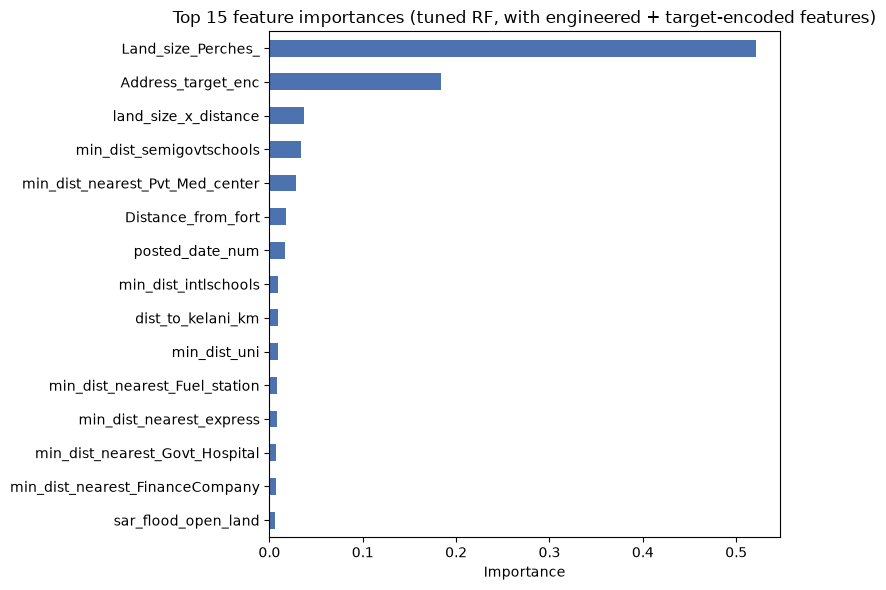

Land_size_Perches_                 0.520845
Address_target_enc                 0.183684
land_size_x_distance               0.037311
min_dist_semigovtschools           0.034017
min_dist_nearest_Pvt_Med_center    0.028888
Distance_from_fort                 0.017871
posted_date_num                    0.016740
min_dist_intlschools               0.009518
dist_to_kelani_km                  0.008775
min_dist_uni                       0.008688
dtype: float64

In [21]:
importances2 = pd.Series(rf_best.feature_importances_, index=feature_cols2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances2.head(15)[::-1].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 feature importances (tuned RF, with engineered + target-encoded features)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

importances2.head(10)

### 10.4 R2 across every stage tried
Random-split scores next to the honest GroupKFold (unseen-division) score, so the gap is visible at a glance.

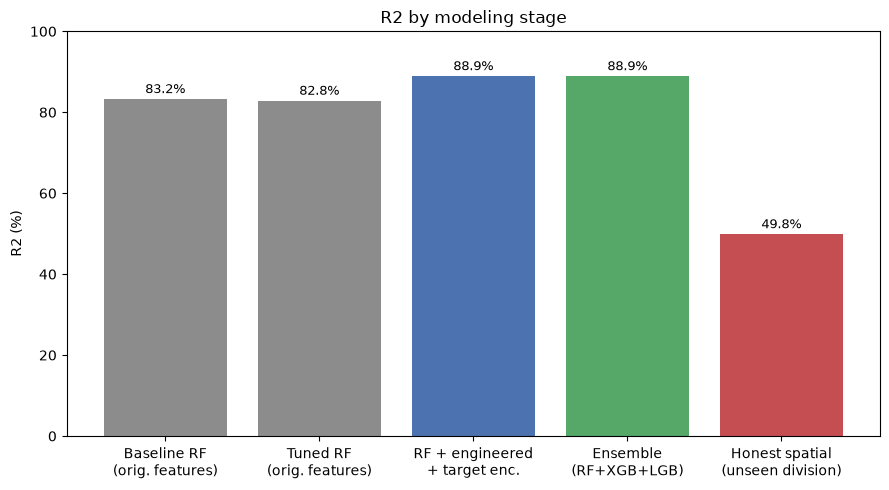

In [22]:
stage_scores = {
    'Baseline RF\n(orig. features)': r2_score(y_test, pred_base) * 100,
    'Tuned RF\n(orig. features)': r2_score(y_test, pred_best) * 100,
    'RF + engineered\n+ target enc.': r2_score(y2_test, pred_rf_tuned) * 100,
    'Ensemble\n(RF+XGB+LGB)': final_r2,
    'Honest spatial\n(unseen division)': fold_scores.mean() * 100,
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#8C8C8C', '#8C8C8C', '#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(stage_scores.keys(), stage_scores.values(), color=colors)
ax.set_ylabel('R2 (%)')
ax.set_title('R2 by modeling stage')
ax.set_ylim(0, 100)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f'{b.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Log results to `model_results_log.csv`

Appends this run's metrics (tagged with `DATA_PATH` and a timestamp) to a single running log so results from every dataset swap are preserved side by side, instead of being overwritten in-notebook.

In [23]:
import os
from datetime import date

run_rows = [
    ('5_baseline', 'RandomForest', r2_score(y_test, pred_base) * 100,
     np.sqrt(mean_squared_error(y_test, pred_base)),
     mean_absolute_percentage_error(np.exp(y_test), np.exp(pred_base)) * 100,
     'n_estimators=300; original features only'),
    ('6_tuned', 'RandomForest', r2_score(y_test, pred_best) * 100,
     np.sqrt(mean_squared_error(y_test, pred_best)),
     mean_absolute_percentage_error(np.exp(y_test), np.exp(pred_best)) * 100,
     'RandomizedSearchCV tuned; original features only'),
    ('8.4_enriched_untuned', 'RandomForest', candidate_results['RandomForest']['r2'],
     candidate_results['RandomForest']['rmse'], candidate_results['RandomForest']['mape'],
     '+engineered features +target-encoded Address'),
    ('8.4_enriched_untuned', 'ExtraTrees', candidate_results['ExtraTrees']['r2'],
     candidate_results['ExtraTrees']['rmse'], candidate_results['ExtraTrees']['mape'],
     '+engineered features +target-encoded Address'),
    ('8.4_enriched_untuned', 'XGBoost', candidate_results['XGBoost']['r2'],
     candidate_results['XGBoost']['rmse'], candidate_results['XGBoost']['mape'],
     '+engineered features +target-encoded Address'),
    ('8.4_enriched_untuned', 'LightGBM', candidate_results['LightGBM']['r2'],
     candidate_results['LightGBM']['rmse'], candidate_results['LightGBM']['mape'],
     '+engineered features +target-encoded Address'),
    ('8.4_enriched_untuned', 'CatBoost', candidate_results['CatBoost']['r2'],
     candidate_results['CatBoost']['rmse'], candidate_results['CatBoost']['mape'],
     '+engineered features +target-encoded Address'),
    ('8.5_enriched_tuned', 'RandomForest', r2_score(y2_test, pred_rf_tuned) * 100,
     np.sqrt(mean_squared_error(y2_test, pred_rf_tuned)),
     mean_absolute_percentage_error(np.exp(y2_test), np.exp(pred_rf_tuned)) * 100,
     'RandomizedSearchCV tuned; enriched feature set'),
    ('8.5_enriched_tuned', 'XGBoost', r2_score(y2_test, pred_xgb_tuned) * 100,
     np.sqrt(mean_squared_error(y2_test, pred_xgb_tuned)),
     mean_absolute_percentage_error(np.exp(y2_test), np.exp(pred_xgb_tuned)) * 100,
     'RandomizedSearchCV tuned; enriched feature set'),
    ('8.5_enriched_tuned', 'LightGBM', r2_score(y2_test, pred_lgb_tuned) * 100,
     np.sqrt(mean_squared_error(y2_test, pred_lgb_tuned)),
     mean_absolute_percentage_error(np.exp(y2_test), np.exp(pred_lgb_tuned)) * 100,
     'RandomizedSearchCV tuned; enriched feature set'),
    ('8.5_enriched_tuned', 'CatBoost', r2_score(y2_test, pred_cat_tuned) * 100,
     np.sqrt(mean_squared_error(y2_test, pred_cat_tuned)),
     mean_absolute_percentage_error(np.exp(y2_test), np.exp(pred_cat_tuned)) * 100,
     'RandomizedSearchCV tuned; enriched feature set'),
    ('8.6_ensemble', 'RF+XGB+LGB+CatBoost avg', r2_score(y2_test, ens_all3) * 100,
     np.sqrt(mean_squared_error(y2_test, ens_all3)),
     mean_absolute_percentage_error(np.exp(y2_test), np.exp(ens_all3)) * 100,
     'best random-split result; plain average of 4 tuned models'),
    ('8.7_spatial_cv', 'RF+XGB+LGB avg', fold_scores.mean() * 100, None, None,
     f'honest GroupKFold by Address (unseen GN division); per-fold R2 {", ".join(f"{s*100:.2f}" for s in fold_scores)}'),
]

log_df = pd.DataFrame(run_rows, columns=['stage', 'model', 'r2_pct', 'rmse_log', 'mape_pct', 'notes'])
log_df.insert(0, 'dataset', DATA_PATH)
log_df.insert(0, 'run_timestamp', date.today().isoformat())

log_path = 'model_results_log.csv'
log_df.to_csv(log_path, mode='a', header=not os.path.exists(log_path), index=False)
print(f'Appended {len(log_df)} rows to {log_path} for dataset={DATA_PATH}')
log_df


Appended 13 rows to model_results_log.csv for dataset=final_dataset_hazard_with_ratnapura.csv


,run_timestamp,dataset,stage,model,r2_pct,rmse_log,mape_pct,notes
0,2026-08-09,final_dataset_hazard_with_ratnapura.csv,5_baseline,RandomForest,83.233203,0.318991,19.375031,n_estimators=300; original features only
1,2026-08-09,final_dataset_hazard_with_ratnapura.csv,6_tuned,RandomForest,82.824391,0.322856,20.010297,RandomizedSearchCV tuned; original features only
2,2026-08-09,final_dataset_hazard_with_ratnapura.csv,8.4_enriched_untuned,RandomForest,88.812826,0.269096,15.752848,+engineered features +target-encoded Address
3,2026-08-09,final_dataset_hazard_with_ratnapura.csv,8.4_enriched_untuned,ExtraTrees,88.387228,0.274166,15.584725,+engineered features +target-encoded Address
4,2026-08-09,final_dataset_hazard_with_ratnapura.csv,8.4_enriched_untuned,XGBoost,88.139596,0.277074,16.251652,+engineered features +target-encoded Address
5,2026-08-09,final_dataset_hazard_with_ratnapura.csv,8.4_enriched_untuned,LightGBM,88.405730,0.273948,18.191471,+engineered features +target-encoded Address
6,2026-08-09,final_dataset_hazard_with_ratnapura.csv,8.4_enriched_untuned,CatBoost,86.781826,0.292504,20.211184,+engineered features +target-encoded Address
7,2026-08-09,final_dataset_hazard_with_ratnapura.csv,8.5_enriched_tuned,RandomForest,88.898465,0.268064,16.043039,RandomizedSearchCV tuned; enriched feature set
8,2026-08-09,final_dataset_hazard_with_ratnapura.csv,8.5_enriched_tuned,XGBoost,88.958242,0.267341,16.913219,RandomizedSearchCV tuned; enriched feature set
9,2026-08-09,final_dataset_hazard_with_ratnapura.csv,8.5_enriched_tuned,LightGBM,88.055577,0.278054,18.024404,RandomizedSearchCV tuned; enriched feature set
